# Section C: Mini Project

**Title:** Cardiac Risk Stratification and Clinical Decision Support System

**Problem Statement:** Develop a diagnostic analytical framework to predict the presence of heart disease, allowing clinicians to prioritize high-risk patients and transition from reactive care to proactive preventive intervention.

**Dataset:** Heart Disease Dataset (UCI)

### Documented EDA & Feature-Target Interaction Matrix

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df_clean = pd.read_csv('cleaned_heart_disease.csv')

In [11]:
df_clean.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,theoretical_max_hr,age_adjusted_thalach_ratio
0,1,1.007386,Male,Cleveland,typical angina,0.675287,0.305908,True,lv hypertrophy,150.0,False,1.303159,downsloping,0.0,fixed defect,0,157,0.904054
1,2,1.432034,Male,Cleveland,asymptomatic,1.462483,0.784599,False,lv hypertrophy,108.0,True,0.569611,flat,3.0,normal,2,153,-0.809447
2,3,1.432034,Male,Cleveland,asymptomatic,-0.636705,0.269780,False,lv hypertrophy,129.0,True,1.578239,flat,2.0,reversable defect,1,153,0.133064
3,4,-1.752828,Male,Cleveland,non-anginal,-0.111908,0.459450,False,normal,187.0,False,2.403480,downsloping,0.0,normal,0,183,1.360316
4,5,-1.328180,Female,Cleveland,atypical angina,-0.111908,0.043982,False,lv hypertrophy,172.0,False,0.477918,upsloping,0.0,normal,0,179,0.941683


In [12]:
key_features = ['age', 'chol', 'thalach', 'oldpeak', 'num']
available_features = [f for f in key_features if f in df_clean.columns]

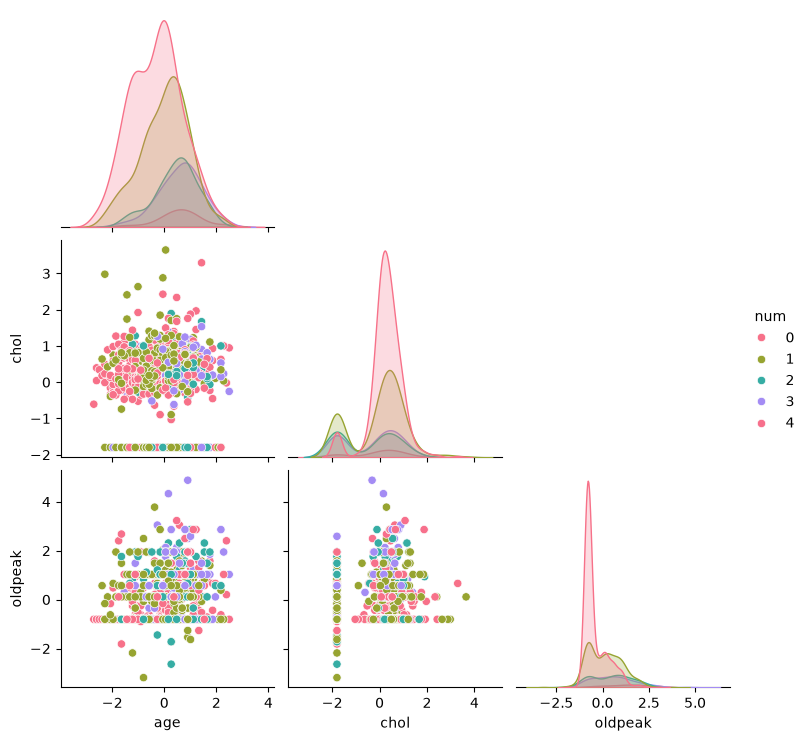

In [13]:
sns.pairplot(df_clean[available_features], hue='num', palette='husl', corner=True)
plt.show()

### Comparison Report: Data Science Predictive Modeling vs. Static Rule-Based Thresholds

#### 1. Context and Limitations of Rule-Based Systems
In traditional clinical settings, risk stratification often relies on static rule-based thresholds, such as flagging patients with `cholesterol > 240` mg/dL or `age > 60` as high risk. While these heuristics are simple to interpret and implement, they suffer from significant limitations:
*   **Oversimplification:** They treat patient health in a binary vacuum. A 30-year-old athlete with high cholesterol is treated identically to a 65-year-old smoker with the same cholesterol level.
*   **Lack of Synergy:** Rules struggle to capture complex, multi-variate interactions. Often, heart disease is the result of compounding minor anomalies across several indicators (e.g., slightly elevated blood pressure *combined with* specific chest pain types) rather than a single massive outlier.

#### 2. The Predictive Modeling Advantage
A Data Science predictive modeling approach utilizes algorithms (like Logistic Regression, Random Forests, or Neural Networks) to holistically evaluate the patient's entire clinical profile simultaneously.
*   **Dynamic Weighting:** Models learn which features are truly indicative of disease (as seen in our correlation heatmaps) and weight them accordingly. For instance, `cp` (chest pain type) and `thalach` (max heart rate) often prove to be stronger predictors than `cholesterol` alone.
*   **Continuous Risk Probability:** Instead of a strict "healthy vs. sick" label, predictive models output a probability score (e.g., 78% risk). This allows clinicians to triage patients smoothly from highest to lowest risk, optimizing resource allocation for proactive interventions.

#### 3. Conclusion for Clinical Decision Support
Transitioning from static rule-based thresholds to a data-driven diagnostic analytical framework fundamentally shifts care from a reactive stance to a proactive one. By leveraging the comprehensive interactions mapped in our EDA, the proposed Clinical Decision Support System can catch high-risk patients earlier, even when individual metrics like cholesterol remain just below standard "danger" thresholds.